<a href="https://colab.research.google.com/github/MattLudu/portfolio/blob/main/optimizaci%C3%B3n_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')
print(f'Versión de matplotlib: {plt.matplotlib.__version__}')

Versión de pandas: 2.2.2
Versión de numpy: 2.0.2
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5
Versión de matplotlib: 3.10.0


In [2]:
datos = pd.read_csv('flights.csv')

In [3]:
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
39121,8,BZ,Airbus A320,schengen,ZQO,15.729617,18.729617,53,2017,False,-6.712981
33794,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,62,2016,False,16.477057
16057,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,340,2012,False,-4.920463
60630,30,BZ,Embraer E175,schengen,PUA,8.923441,12.923441,27,2021,False,8.446481
2088,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,139,2010,False,29.596005


In [4]:
datos.shape

(71175, 11)

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [7]:
 datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [9]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


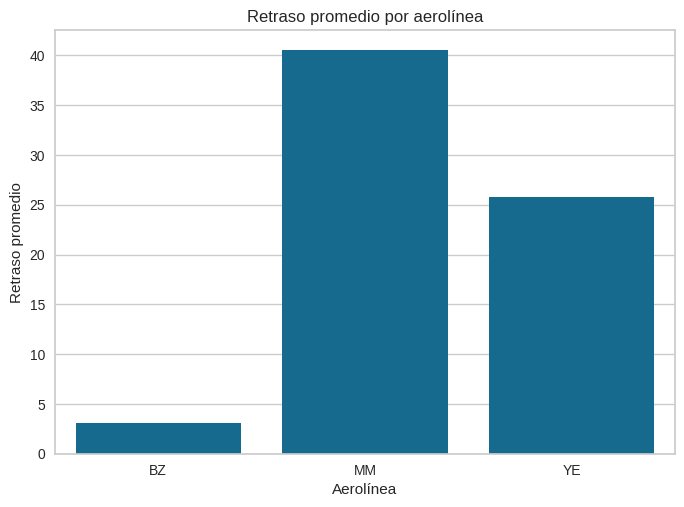

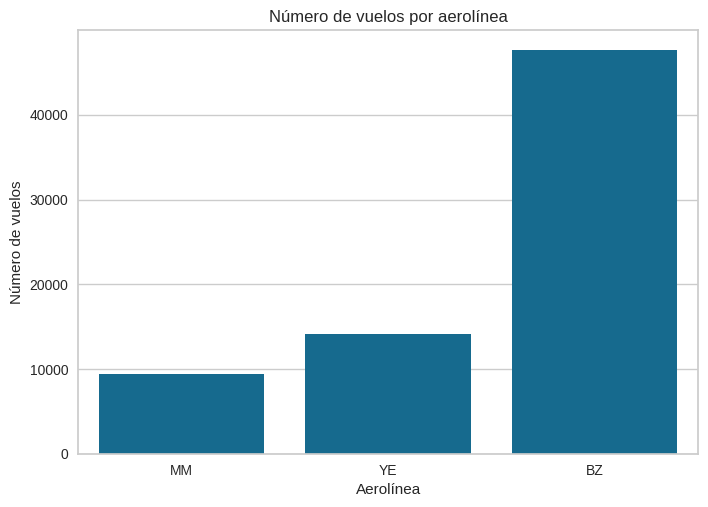

In [11]:
 avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
 sns.barplot(x='airline', y='delay', data=avg_delay)
 plt.title('Retraso promedio por aerolínea')
 plt.xlabel('Aerolínea')
 plt.ylabel('Retraso promedio')
 plt.show()

 sns.countplot(x='airline', data=datos)
 plt.title('Número de vuelos por aerolínea')
 plt.xlabel('Aerolínea')
 plt.ylabel('Número de vuelos')
 plt.show()

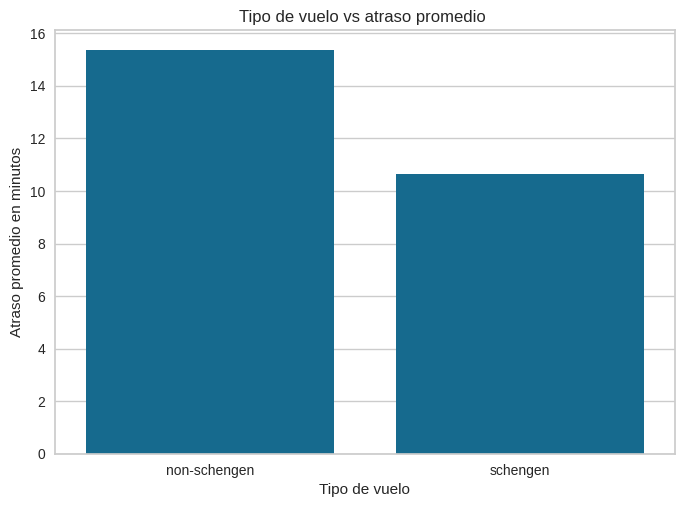

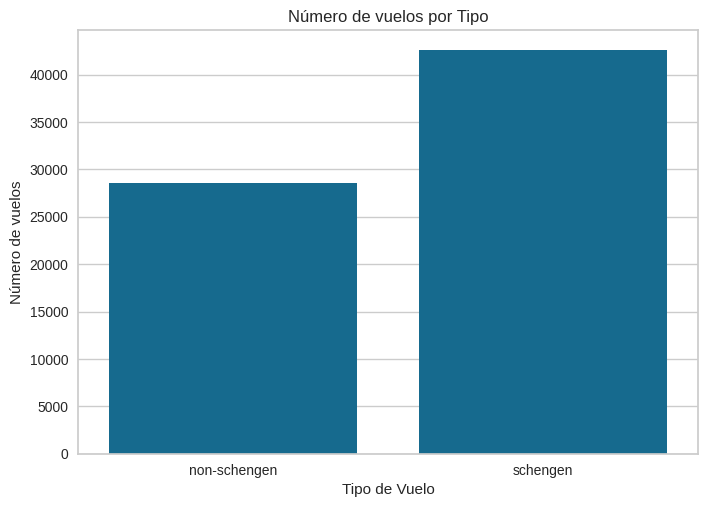

In [13]:
 avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
 sns.barplot(x='schengen', y='delay', data=avg_delay)
 plt.title('Tipo de vuelo vs atraso promedio ')
 plt.xlabel('Tipo de vuelo')
 plt.ylabel('Atraso promedio en minutos')
 plt.show()

 sns.countplot(x='schengen', data=datos)
 plt.title('Número de vuelos por Tipo')
 plt.xlabel('Tipo de Vuelo')
 plt.ylabel('Número de vuelos')
 plt.show()

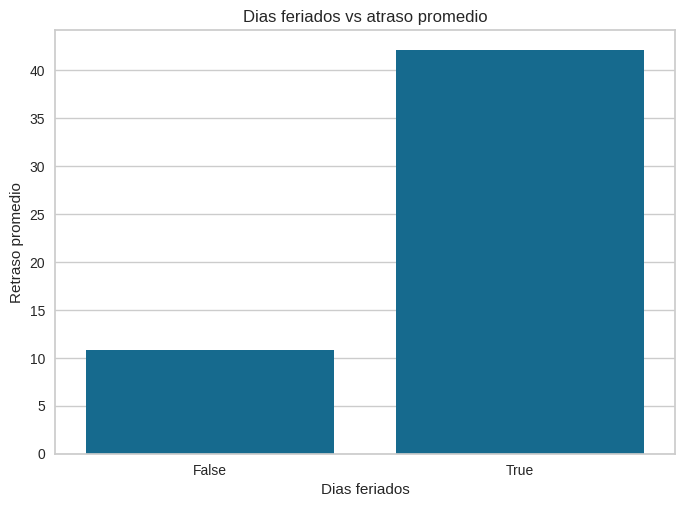

In [14]:
 avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
 sns.barplot(x='is_holiday', y='delay', data=avg_delay)
 plt.title('Dias feriados vs atraso promedio')
 plt.xlabel('Dias feriados')
 plt.ylabel('Retraso promedio')
 plt.show()

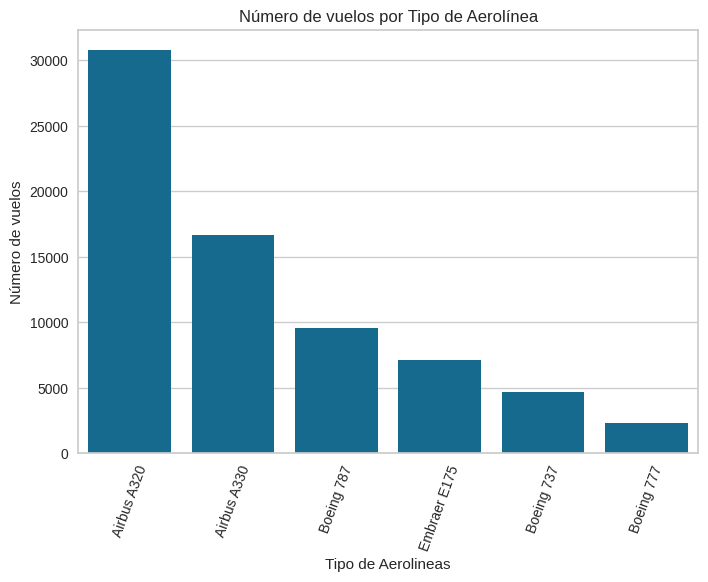

In [15]:
order = datos['aircraft_type'].value_counts().index
sns.countplot(x='aircraft_type', data=datos,order=order)
plt.title('Número de vuelos por Tipo de Aerolínea')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aerolineas')
plt.ylabel('Número de vuelos')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

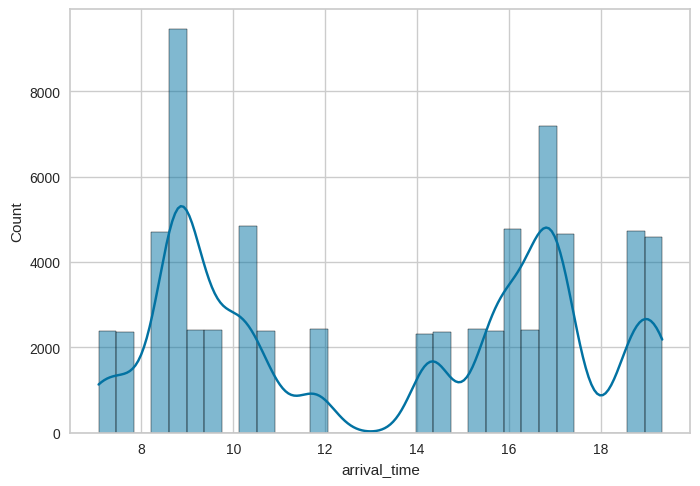

In [17]:
sns.histplot(data=datos, x = 'arrival_time', kde=True)

In [18]:
def ancho_bin(df, columna):
    q75,q25 = np.percentile(df[columna],[75,25])
    iqr = q75 - q25
    ancho = 2*iqr*np.power(len(df[columna]),-1/3)
    return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

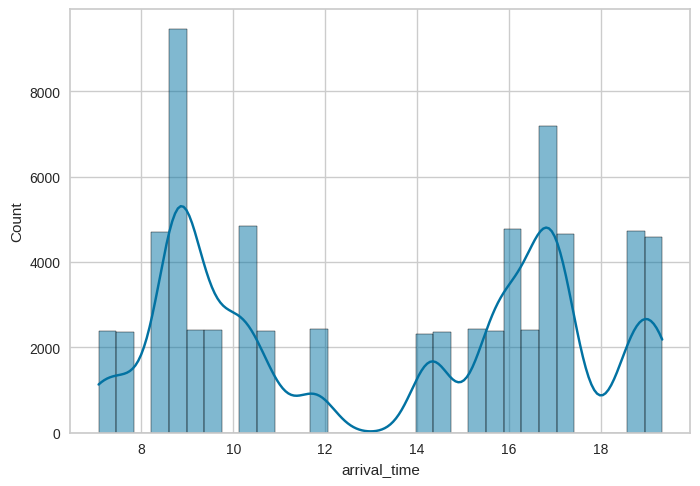

In [19]:
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth)


<Axes: xlabel='arrival_time', ylabel='Count'>

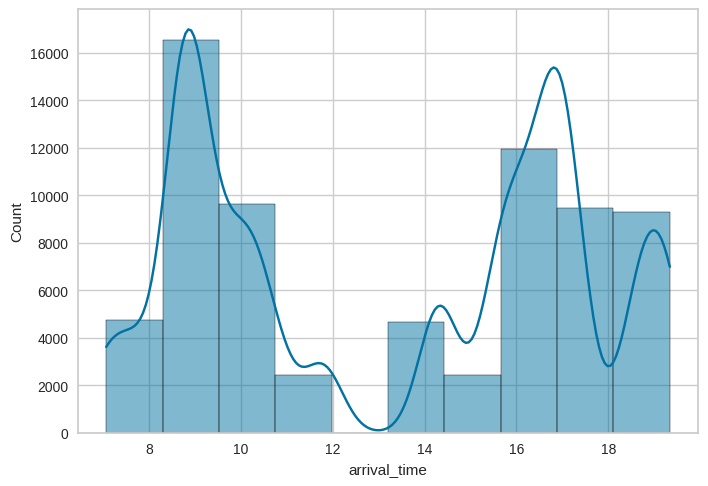

In [20]:
sns.histplot(data=datos,x='arrival_time',kde=True,bins=10)

<Axes: xlabel='departure_time', ylabel='Count'>

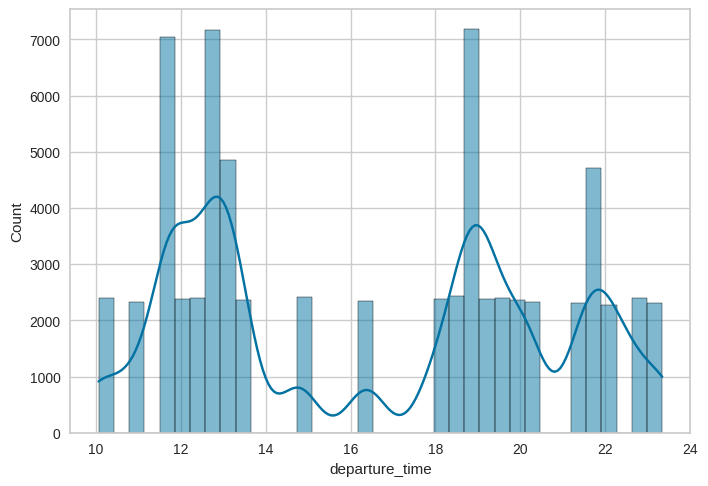

In [21]:
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth)

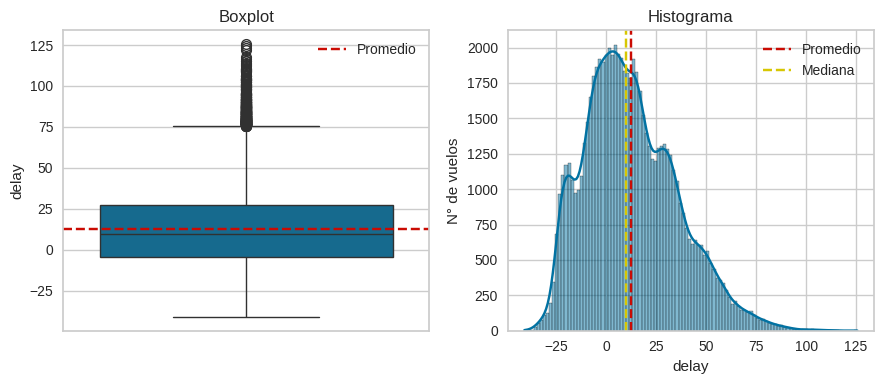

In [32]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

fig, ax = plt.subplots(1, 2, figsize=(9, 4))

sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

binwidth = ancho_bin(datos, 'delay')
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
ax[1].set_ylabel('N° de vuelos')
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label='Mediana')
ax[1].legend()

plt.tight_layout()
plt.show()


In [33]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [ ]:
datos = datos.drop(columns=['datos'])

In [37]:
datos['date'] = datos['year'].astype(str) + '-' + (datos['day']+1).astype(str)
datos['date'] = pd.to_datetime(datos['date'],format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [40]:
  datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
  datos['day_name'] = datos['date'].dt.day_name()
  datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
49242,21,BZ,Boeing 737,schengen,FJB,7.065594,10.065594,362,2018,False,16.190949,2018-12-29,True,Saturday
59712,19,MM,Airbus A320,schengen,TZF,16.245220,19.245220,330,2020,False,32.076782,2020-11-26,False,Thursday
62337,13,BZ,Boeing 787,non-schengen,TCY,10.172731,13.172731,140,2021,False,2.542134,2021-05-21,False,Friday
12142,30,BZ,Embraer E175,schengen,PUA,8.923441,12.923441,79,2012,False,-2.604098,2012-03-20,False,Tuesday
24640,24,BZ,Airbus A320,schengen,FJB,9.668655,12.668655,182,2014,False,17.965653,2014-07-02,False,Wednesday


In [41]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [44]:
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
4937,1,BZ,Airbus A320,0,CNU,15.496519,18.496519,329,2010,0,36.633082,2010-11-26,0,Friday
42867,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,302,2017,0,-2.648547,2017-10-30,0,Monday
71135,30,BZ,Embraer E175,1,PUA,8.923441,12.923441,362,2022,0,2.142097,2022-12-29,0,Thursday


In [45]:
categoricas = ['airline','aircraft_type','origin','day_name']

pd.get_dummies(data=datos,columns=categoricas,dtype=int).head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


In [47]:
 datos_codificados = pd.get_dummies(data=datos,columns=categoricas,dtype=int)
 datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
62087,17,0,16.718722,21.718722,124,2021,0,-4.720075,2021-05-05,0,...,0,0,0,0,0,0,0,0,0,1
42856,26,0,8.885071,10.885071,302,2017,0,35.792849,2017-10-30,0,...,1,0,0,0,1,0,0,0,0,0
67304,8,1,15.729617,18.729617,106,2022,0,-5.927335,2022-04-17,1,...,0,0,1,0,0,0,1,0,0,0
16390,3,1,18.635384,22.635384,362,2012,0,-24.958024,2012-12-28,0,...,0,1,0,1,0,0,0,0,0,0
60453,4,1,11.781391,14.781391,15,2021,0,-24.552486,2021-01-16,1,...,1,0,0,0,0,1,0,0,0,0


In [48]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [49]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [50]:
df = datos_codificados.drop(columns=['flight_id','year','day','departure_time','date'])
df.sample(5)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
30182,1,7.708301,0,-9.395798,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
60661,0,16.718722,0,8.604254,1,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
67902,0,17.041281,0,76.979440,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
50027,1,7.065594,0,21.780033,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
20243,0,8.939996,0,34.364918,0,0,0,1,1,0,...,1,0,0,0,0,0,0,1,0,0


https://scikit-learn.org/stable/index.html

In [51]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X = df.drop(columns=['delay'], axis=1)
y = df['delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

baseline = DummyRegressor()
baseline.fit(X_train, y_train)

DummyRegressor()

In [52]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [59]:
y_pred_dummy = baseline.predict(X_test)

def calcular_regresion(y_test,y_pred):
    rmse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    metricas = {
        'RMSR':round(rmse**(1/2),4),
        'MAE':round(mae,4),
        'R2':round(r2,4)
        }
    return metricas

In [60]:
resultados_baseline = calcular_regresion(y_test,y_pred_dummy)
resultados_baseline

{'RMSR': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

In [63]:
from sklearn.ensemble import RandomForestRegressor

In [64]:
modelo = RandomForestRegressor(max_depth=5,random_state=42)
modelo.fit(X_train,y_train)
ypred = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test,ypred)
resultados_rf

{'RMSR': 13.7479, 'MAE': 11.0262, 'R2': 0.6477}

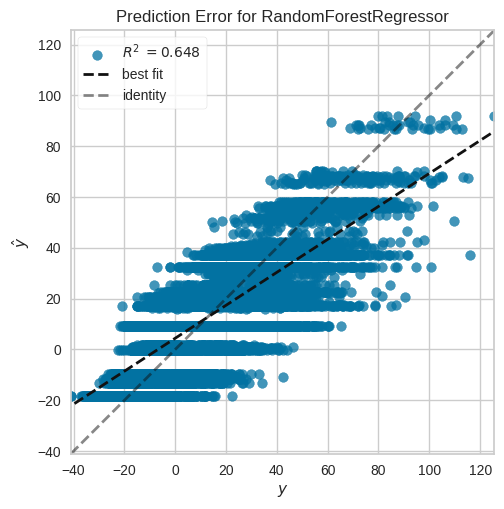

In [65]:
from yellowbrick.regressor import prediction_error

vizualizador = prediction_error(modelo,X_train,y_train,X_test,y_test);

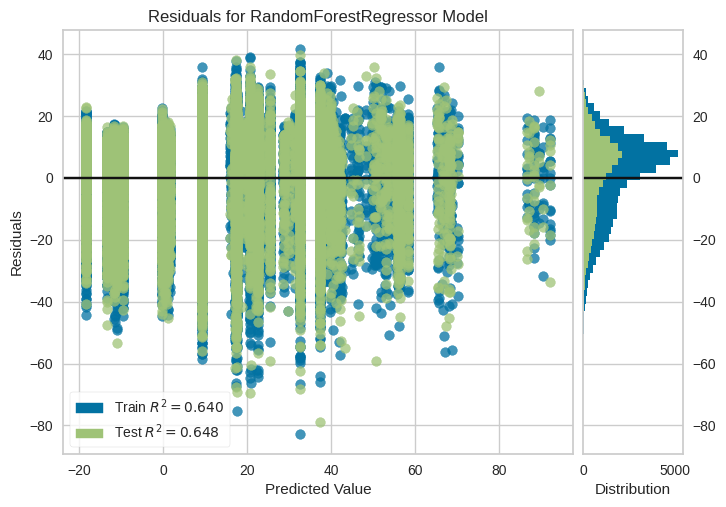

In [67]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo,X_train,y_train,X_test,y_test);

In [71]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'MAE':'neg_mean_absolute_error',
    'RMSE':'neg_root_mean_squared_error',
    'R2':'r2'
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)

cv_results


{'fit_time': array([3.25127625, 3.40349579, 2.409168  , 2.49698114, 2.43398499]),
 'score_time': array([0.05231929, 0.05218649, 0.05252433, 0.05332065, 0.0518887 ]),
 'test_MAE': array([-11.03252135, -11.13534968, -11.2094657 , -11.14503717,
        -11.25775565]),
 'test_RMSE': array([-13.76989748, -13.86928373, -13.96807668, -13.85347402,
        -13.98953528]),
 'test_R2': array([0.64559466, 0.63745663, 0.63523823, 0.64089302, 0.63441267])}

In [72]:
len(df.columns)

31

In [73]:
modelo.feature_importances_

array([3.39814918e-06, 3.60417588e-02, 1.45895991e-01, 6.10861947e-05,
       5.30319673e-01, 1.36989042e-05, 2.14417900e-05, 1.00746574e-01,
       5.76173558e-02, 5.18974843e-04, 8.83162236e-05, 2.64390542e-02,
       4.58830752e-02, 1.01922847e-04, 1.71891675e-04, 1.59736760e-02,
       3.57450957e-05, 9.21269997e-05, 5.42552087e-04, 1.03212932e-02,
       2.09099647e-02, 6.63707069e-03, 2.64070312e-04, 8.68597522e-04,
       1.00052465e-04, 2.79146627e-05, 7.17673254e-05, 3.72705034e-05,
       1.06499638e-04, 8.71862374e-05])

In [74]:
importances = modelo.feature_importances_

In [75]:
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,53.03
2,is_holiday,14.59
7,aircraft_type_Airbus A320,10.07
8,aircraft_type_Airbus A330,5.76
12,aircraft_type_Embraer E175,4.59
1,arrival_time,3.60
11,aircraft_type_Boeing 787,2.64
20,origin_TCY,2.09
15,origin_CSF,1.60
19,origin_PUA,1.03


In [76]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

for i in ct_features:
  selected_features = feature_importances['Features'][:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel,y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7498,13.7477,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0280,11.0261,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6476,0.6477,0.6477


In [78]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = range(10,16)

for i in ct_features:
  selected_features = feature_importances['Features'][:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel,y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

,10,11,12,13,14,15
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476


In [79]:
selected_features = feature_importances['Features'][:13]
X_selected_features = X[selected_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,origin_MWL
0,0,0,1,0,0,8.885071,0,1,0,0,0,1,0
1,0,0,1,0,0,8.939996,0,1,0,0,0,1,0
2,1,0,0,0,1,18.635384,0,0,0,0,1,1,0
3,1,0,0,1,0,15.967963,0,0,0,0,0,1,0
4,1,0,0,1,0,16.571894,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1,1,0,0,1,18.635384,0,0,0,0,1,0,0
71171,1,1,0,1,0,16.718722,0,0,0,0,0,0,0
71172,0,1,0,0,0,8.564949,1,0,0,0,1,0,0
71173,1,1,1,0,0,9.344097,0,0,0,0,0,0,0


In [80]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y, random_state=42)

In [81]:
param_grid = {
              'max_depth': [5, 10, 15],
              'min_samples_split': [2,4,6],
              'min_samples_leaf': [1, 2, 3],
              'n_estimators': [100, 150, 200]
              }


In [82]:
from sklearn.model_selection import GridSearchCV

In [84]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid, cv=cv, scoring='r2')
model_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [85]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [86]:
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid

{'RMSR': 13.2308, 'MAE': 10.6296, 'R2': 0.6754}

In [89]:
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,10,11,12,13,14,15,modelo_grid
RMSE,13.7587,13.7564,13.7526,13.7526,13.7497,13.7497,13.2308
MAE,11.0422,11.0425,11.0312,11.0314,11.0285,11.0285,10.6296
R2,0.6471,0.6472,0.6474,0.6474,0.6476,0.6476,0.6754


In [91]:
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(model_grid.best_estimator_,file)
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo',str(e))

Modelo serializado con éxito
